In [1]:
!pip install rasterio geopandas ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 13.4 MB/s eta 0:00:00


In [2]:
import os, random, shutil, rasterio, torch, cv2, time, gc, logging, psutil

import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib import colors, patches
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from rasterio.windows import Window
from rasterio.features import shapes
from rasterio.transform import Affine
from shapely.geometry import Polygon, Point, MultiPolygon, box, shape

from ultralytics import YOLO
from IPython.display import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
Starting optimized tree detection at 0.5x resolution...
Batch size: 4
Original image size: 40244x25007
Processing 160 tiles...


Rows: 100%|██████████| 10/10 [03:26<00:00, 20.69s/it]


Total detections: 2668

Detection complete! Creating visualization...


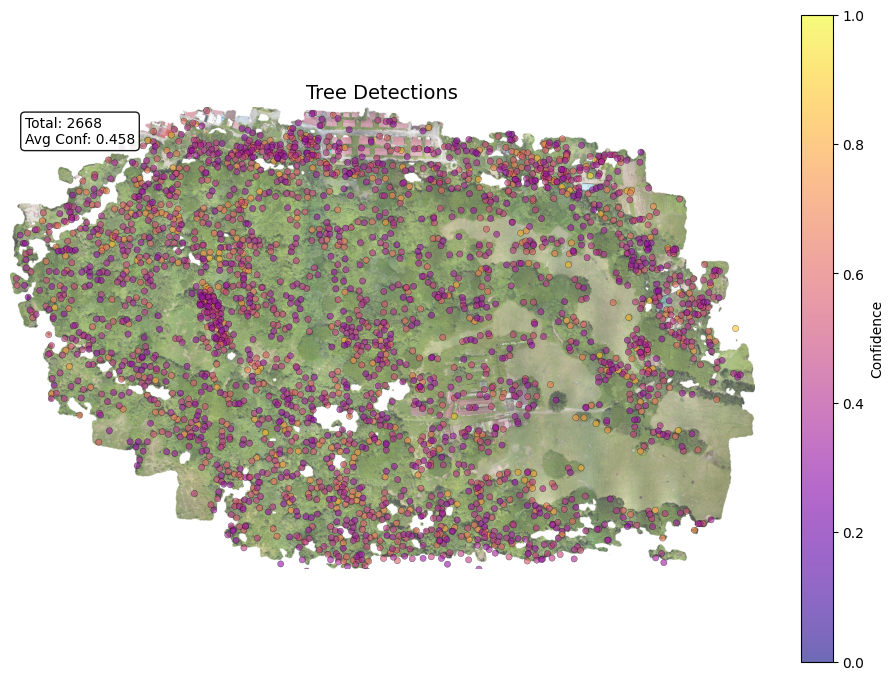

✓ Saved GeoJSON

DETECTION SUMMARY
Total detections: 2668
Average confidence: 0.458
Confidence range: 0.300 - 0.923
Memory usage: 0.27 MB (estimated)

SAVED FILES
✓ tree_detections.csv
✓ tree_points.geojson
✓ tree_boxes.csv
✓ tile_counts.csv
✓ tree_detections.png

CPU time used: 229.25 seconds
Processing speed: 11.6 detections/sec


In [4]:
# Enable memory efficient settings
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('medium')

start_cpu_time = time.process_time()

# Load model with optimizations
new_model = YOLO('/content/drive/MyDrive/AGRI/Tree_Detection/models/yolo11n-100epoch-v2.pt')
new_model.fuse()  # Fuse layers for inference speed
new_model.to('cuda' if torch.cuda.is_available() else 'cpu')

# Use half precision if GPU is available
if torch.cuda.is_available():
    new_model.half()

def detect_single_resolution_optimized(image_path, model, output_dir,
                                      tile_size=1280, overlap=0,
                                      resolution=0.5, conf_threshold=0.3):
    """
    Memory-efficient detection:
    - Tiles are read directly from the file
    - No full-image in-memory resizing
    - Small batches processed at a time
    """
    all_points = []
    detection_points_pixel = []
    detection_boxes = []
    counts_per_tile = []

    try:
        with rasterio.open(image_path) as src:
            transform = src.transform
            crs = src.crs
            original_width, original_height = src.width, src.height
            print(f"Original image size: {original_width}x{original_height}")

            # Compute scaled tile size in original pixels
            tile_size_scaled = int(tile_size / resolution)
            step = tile_size_scaled - int(overlap / resolution)

            y_positions = np.arange(0, original_height, step)
            x_positions = np.arange(0, original_width, step)

            total_tiles = len(y_positions) * len(x_positions)
            print(f"Processing {total_tiles} tiles...")

            tile_idx = 0
            for y in tqdm(y_positions, desc="Rows"):
                for x in x_positions:
                    x_end = min(x + tile_size_scaled, original_width)
                    y_end = min(y + tile_size_scaled, original_height)
                    if x_end - x < 32 or y_end - y < 32:
                        continue

                    # Read only the tile window directly from file
                    window = rasterio.windows.Window(x, y, x_end - x, y_end - y)
                    tile = src.read([1,2,3], window=window)
                    tile = np.transpose(tile, (1,2,0))  # HWC
                    tile_resized = cv2.resize(tile, (tile_size, tile_size), interpolation=cv2.INTER_LINEAR)

                    # Move tile to GPU if available
                    if torch.cuda.is_available():
                        device = 'cuda'
                    else:
                        device = 'cpu'

                    # Predict
                    results = model.predict([tile_resized], conf=conf_threshold,
                                            save=False, verbose=False, imgsz=tile_size)

                    result = results[0]
                    if result.boxes is not None and len(result.boxes) > 0:
                        boxes = result.boxes.xyxy.cpu().numpy()
                        confidences = result.boxes.conf.cpu().numpy()

                        # Scale boxes back to original coordinates
                        scale = (x_end - x)/tile_size
                        bx_scaled = boxes * scale

                        # Compute centers
                        centers_x = bx_scaled[:, 0] + (bx_scaled[:, 2]-bx_scaled[:,0])/2
                        centers_y = bx_scaled[:, 1] + (bx_scaled[:, 3]-bx_scaled[:,1])/2

                        # Global positions
                        global_x = x + centers_x
                        global_y = y + centers_y

                        # Save points
                        for i in range(len(boxes)):
                            px, py = rasterio.transform.xy(transform, global_y[i], global_x[i])
                            detection_points_pixel.append({
                                'x': float(global_x[i]),
                                'y': float(global_y[i]),
                                'confidence': float(confidences[i]),
                                'tile_id': tile_idx
                            })
                            all_points.append(Point(float(px), float(py)))
                            detection_boxes.append({
                                'x1': float(global_x[i] + (bx_scaled[i,0]-bx_scaled[i,0])),
                                'y1': float(global_y[i] + (bx_scaled[i,1]-bx_scaled[i,1])),
                                'x2': float(global_x[i] + (bx_scaled[i,2]-bx_scaled[i,0])),
                                'y2': float(global_y[i] + (bx_scaled[i,3]-bx_scaled[i,1])),
                                'confidence': float(confidences[i]),
                                'tile_id': tile_idx
                            })

                        counts_per_tile.append({
                            "tile_id": tile_idx,
                            "count": len(boxes),
                            "x": x, "y": y,
                            "width": x_end-x, "height": y_end-y
                        })
                    else:
                        counts_per_tile.append({
                            "tile_id": tile_idx,
                            "count": 0,
                            "x": x, "y": y,
                            "width": x_end-x, "height": y_end-y
                        })

                    tile_idx += 1

                    # Clean memory after each tile
                    del tile, tile_resized, results, result
                    gc.collect()
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()

    except Exception as e:
        print(f"Error in detection: {e}")
        raise

    print(f"Total detections: {len(detection_points_pixel)}")
    return all_points, detection_points_pixel, detection_boxes, counts_per_tile


def visualize_detections_efficient(image_path, detection_points_pixel, output_dir,
                                   bands=[1, 2, 3], sample_fraction=1.0):
    """
    Efficient visualization with downsampling option
    """
    if not detection_points_pixel:
        print("No detections to visualize")
        return

    fig, ax = plt.subplots(figsize=(12, 12))
    ax.set_title("Tree Detections", fontsize=14)
    ax.set_axis_off()

    try:
        with rasterio.open(image_path) as src:
            width, height = src.width, src.height

            # Downsample the background for faster plotting
            max_display_pixels = 2000 * 2000
            if width * height > max_display_pixels:
                scale = np.sqrt(max_display_pixels / (width * height))
                display_width = int(width * scale)
                display_height = int(height * scale)

                # Read and resize
                background_img = src.read(bands)
                background_img = np.transpose(background_img, (1, 2, 0))
                background_img = cv2.resize(background_img, (display_width, display_height),
                                          interpolation=cv2.INTER_AREA)
                # Scale coordinates for display
                x_scale = display_width / width
                y_scale = display_height / height

                # Extract coordinates with sampling
                if sample_fraction < 1.0:
                    sample_size = int(len(detection_points_pixel) * sample_fraction)
                    indices = np.random.choice(len(detection_points_pixel),
                                              sample_size, replace=False)
                    x_coords = [detection_points_pixel[i]['x'] * x_scale for i in indices]
                    y_coords = [detection_points_pixel[i]['y'] * y_scale for i in indices]
                    confidences = [detection_points_pixel[i]['confidence'] for i in indices]
                else:
                    x_coords = [d['x'] * x_scale for d in detection_points_pixel]
                    y_coords = [d['y'] * y_scale for d in detection_points_pixel]
                    confidences = [d['confidence'] for d in detection_points_pixel]

                ax.imshow(background_img / 255.0, extent=[0, display_width, display_height, 0],
                         alpha=0.7)
                ax.set_xlim(0, display_width)
                ax.set_ylim(display_height, 0)

            else:
                # Original size
                background_img = src.read(bands)
                background_img = np.transpose(background_img, (1, 2, 0))

                if sample_fraction < 1.0:
                    sample_size = int(len(detection_points_pixel) * sample_fraction)
                    indices = np.random.choice(len(detection_points_pixel),
                                              sample_size, replace=False)
                    x_coords = [detection_points_pixel[i]['x'] for i in indices]
                    y_coords = [detection_points_pixel[i]['y'] for i in indices]
                    confidences = [detection_points_pixel[i]['confidence'] for i in indices]
                else:
                    x_coords = [d['x'] for d in detection_points_pixel]
                    y_coords = [d['y'] for d in detection_points_pixel]
                    confidences = [d['confidence'] for d in detection_points_pixel]

                ax.imshow(background_img / 255.0, extent=[0, width, height, 0], alpha=0.7)
                ax.set_xlim(0, width)
                ax.set_ylim(height, 0)

            # Create scatter plot
            scatter = ax.scatter(x_coords, y_coords, c=confidences, cmap='plasma',
                               s=20, alpha=0.6, edgecolors='black', linewidths=0.3,
                               vmin=0, vmax=1)

            plt.colorbar(scatter, ax=ax, label='Confidence', shrink=0.7)

            avg_conf = np.mean(confidences)
            stats_text = f"Total: {len(detection_points_pixel)}\nAvg Conf: {avg_conf:.3f}"
            if sample_fraction < 1.0:
                stats_text += f"\nDisplayed: {len(x_coords)}"

            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
                   verticalalignment='top', bbox=dict(boxstyle="round", fc="white", alpha=0.9))

    except Exception as e:
        print(f"Error in visualization: {e}")
        plt.close()
        return

    # Save with compression
    plt.savefig(f'{output_dir}/tree_detections.png', dpi=150, bbox_inches='tight', pil_kwargs={'compress_level': 6})
    plt.show()
    plt.close()


# Configuration
tile_size = 1280
overlap = 0
resolution = 0.50
conf_threshold = 0.30
batch_size = 4  # Process multiple tiles at once
bands = [1, 2, 3]
image_path = '/content/drive/MyDrive/AGRI/TreeCrown_Segmentation/ortho_872.tif'
output_dir = '/content/drive/MyDrive/AGRI/Detection'

print(f"Starting optimized tree detection at {resolution}x resolution...")
print(f"Batch size: {batch_size}")

# Clear cache before starting
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Run detection
all_points, detection_points_pixel, detection_boxes, counts_per_tile = detect_single_resolution_optimized(
    image_path=image_path,
    model=new_model,
    output_dir=output_dir,
    tile_size=tile_size,
    overlap=overlap,
    resolution=resolution,
    conf_threshold=conf_threshold,
    #batch_size=batch_size
)

print("\nDetection complete! Creating visualization...")

# Create efficient visualization (display only 20% of points if many)
if len(detection_points_pixel) > 5000:
    sample_frac = 5000 / len(detection_points_pixel)
    print(f"Large dataset ({len(detection_points_pixel)} points), displaying {5000} samples")
else:
    sample_frac = 1.0

visualize_detections_efficient(image_path, detection_points_pixel, output_dir,
                              bands, sample_fraction=sample_frac)

# Save results with memory efficiency
if detection_points_pixel:
    # Convert to DataFrames in chunks to avoid memory issues
    chunk_size = 50000

    # Save detection points in chunks if large
    if len(detection_points_pixel) > chunk_size:
        for i in range(0, len(detection_points_pixel), chunk_size):
            chunk = detection_points_pixel[i:i+chunk_size]
            df_chunk = pd.DataFrame(chunk)
            mode = 'w' if i == 0 else 'a'
            header = i == 0
            df_chunk.to_csv(f'{output_dir}/tree_detections.csv',
                          index=False, mode=mode, header=header)
    else:
        df_detections = pd.DataFrame(detection_points_pixel)
        df_detections.to_csv(f'{output_dir}/tree_detections.csv', index=False)

    # Save as GeoJSON (simplify geometry if large)
    if all_points:
        if len(all_points) > 100000:
            print("Large point set, simplifying...")
            # Keep only every 10th point for very large datasets
            all_points = all_points[::10]
            detection_points_pixel = detection_points_pixel[::10]

        gdf_points = gpd.GeoDataFrame(geometry=all_points, crs='EPSG:4326')
        gdf_points['confidence'] = [d['confidence'] for d in detection_points_pixel]
        gdf_points['tile_id'] = [d['tile_id'] for d in detection_points_pixel]

        try:
            # Save with compression
            gdf_points.to_file(f"{output_dir}/tree_points.geojson",
                             driver="GeoJSON")
            print("✓ Saved GeoJSON")
        except Exception as e:
            print(f"⚠ Could not save GeoJSON: {e}")
            # Try saving as shapefile instead
            try:
                gdf_points.to_file(f"{output_dir}/tree_points.shp")
                print("✓ Saved as Shapefile instead")
            except Exception as e2:
                print(f"⚠ Could not save shapefile either: {e2}")

    # Save other results
    if detection_boxes:
        pd.DataFrame(detection_boxes).to_csv(f'{output_dir}/tree_boxes.csv', index=False)

    if counts_per_tile:
        pd.DataFrame(counts_per_tile).to_csv(f'{output_dir}/tile_counts.csv', index=False)

# Print summary
print(f"\n{'='*50}")
print(f"DETECTION SUMMARY")
print(f"{'='*50}")
print(f"Total detections: {len(detection_points_pixel)}")
if detection_points_pixel:
    confidences = [d['confidence'] for d in detection_points_pixel]
    avg_conf = np.mean(confidences)
    print(f"Average confidence: {avg_conf:.3f}")
    print(f"Confidence range: {min(confidences):.3f} - {max(confidences):.3f}")
    print(f"Memory usage: {len(detection_points_pixel) * 100 / 1e6:.2f} MB (estimated)")

print(f"\n{'='*50}")
print(f"SAVED FILES")
print(f"{'='*50}")
print(f"✓ tree_detections.csv")
print(f"✓ tree_points.geojson")
print(f"✓ tree_boxes.csv")
print(f"✓ tile_counts.csv")
print(f"✓ tree_detections.png")

end_cpu_time = time.process_time()
cpu_time_used = end_cpu_time - start_cpu_time
print(f"\n{'='*50}")
print(f"CPU time used: {cpu_time_used:.2f} seconds")
print(f"Processing speed: {len(detection_points_pixel)/cpu_time_used:.1f} detections/sec")
print(f"{'='*50}")

# Final cleanup
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()